In [1]:
# import everything first:
import numpy as np
import astropy.constants as const
import astropy.units as u
from matplotlib import pyplot as plt

In [2]:
# Constants
G = 6.674e-8        # cm^3 g^-1 s^-2
sigmaB = 5.67e-5    # erg cm^-2 s^-1 K^-4
kB = 1.381e-16      # erg/K
L_sun = 3.828e33    # erg/s
R_p = 7.149e9       # Jupiter radius in cm
AU = 1.496e13       # cm
L_jup = 3.846e30  # erg/s

# Physical constants
M_sun = 1.989e33 
M_jup = 1.898e30
R_jup = 7.149e9
#AU = 1.496e13
sec_per_yr = 3.156e7
Rgas = 8.314e7  # erg/(mol K)


In [29]:
def B_lambda(lam, T):
    """
    Planck function in wavelength (erg s^-1 cm^-2 Hz^-1 sr^-1)
    lam: wavelength in cm
    T: temperature in K
    """
    h = 6.626e-27  # erg*s
    c = 2.998e10   # cm/s
    k = 1.381e-16  # erg/K
    return (2*h*c**2 / lam**5) / (np.exp(h*c/(lam*k*T)) - 1)


def calculate_disk_properties(M_star = 1, Mp = 1, Mdot = 1e-5, alpha = 1e-3, kappaR = 10 , Rin = 1, rp = 165, d_pc = 195, 
                            mode="b", lam_mm=1.3e-1, 
                            T_ISM=10.0, Lplanet=1e-5, Lstar = 1.0,  mu=2.3, spec_flux  = None , show_results = False):
    """
    Calculate disk temperature profiles and millimeter flux.
    
    Parameters:
    -----------
    M_star : float
        Stellar mass (M_sun)

    Mp : float
        Planet mass (M_jup)
    Mdot : float  
        Accretion rate (M_jup/yr)
    alpha : float
        Viscosity parameter
    kappaR : float
        Rosseland opacity (cm^2/g)
    Rin : float
        Inner radius (Rjup)
    Rp : float
        distance of planet from star (au)  
    d_pc : float
        Distance (pc)
    mode : str
        Irradiation mode: "b", "no_b", or "planet"
    lam_mm : float
        Wavelength (mm)
    T_ISM : float
        Interstellar medium temperature (K)
    Lplanet : float
        Planet luminosity (L_sun)
    mu : float
        Mean molecular weight

    Lstar : float
        Stellar luminosity (L_sun)
        
    Returns:
    --------
    dict : Dictionary containing R, temperatures, Sigma, tau_mm, Tb, F_nu_tot
    """
    # Turn input values to cgs
    # Disk parameters
    M_star = M_star * M_sun
    Mp = Mp * M_jup
    Mdot = Mdot * M_jup / sec_per_yr
    Rin = Rin * R_jup
    rp = rp * AU

    # Turn the luminosites to erg/s
    Lplanet = Lplanet * L_sun
    Lstar = Lstar * L_sun
    
    # 1. Create radial grid between Rin and Rout

    Rout = (1/3) * rp * (Mp / (3 * M_star))**(1/3)
    R = np.geomspace(Rin, Rout, 100)  # cm
    
    # 2. Calculate T_ext(R)
    #if mode == "b":
    #    L_irr = G * Mp * Mdot / (2.0 * R_p)
    #elif mode == "no_b":
    #    L_irr = 0.0
    #elif mode == "planet":
    #    L_irr = Lplanet
    #else:
    #    raise ValueError("mode must be 'b', 'no_b', or 'planet'")

    L_irr = G * Mp * Mdot / (2.0 * R_p)   # accretion luminosity
    
    #T_irr = 0.0 if L_irr == 0.0 else 
    
    T_irr = (L_irr / (40 * np.pi * sigmaB * R**2))**0.25
    
    #print(f'L_irr = {L_irr/L_sun:.2e} L_sun')

    # Planet irradiation

    T_irr_p = (0.1 * Lplanet  / (4 * np.pi * sigmaB * R**2))**0.25  # K  , R is coordinate in CPD frame

    # Star irradiation

    phi_flare = 0.02   # flaring angle of the host disk   (Huang et al. (2018b))

    T_irr_star = (phi_flare * Lstar / (8 * np.pi * sigmaB * rp**2))**0.25  # K

    T_ext = (T_irr**4 + T_irr_p**4 + T_irr_star**4 + T_ISM**4)**0.25  # K
    # T_ext = (T_irr**4 + T_ISM**4)**0.25  # K
    
    # 3. Calculate T_eff(R)
    Teff = ((3.0 * G * Mp * Mdot) / (8.0 * np.pi * sigmaB * R**3) * 
            (1.0 - np.sqrt(Rin / R)))**0.25  # K
    
    # 4. Calculate Sigma(R)
    Rgas = 8.314e7  # erg/(mol K)
    
    # Sigma prescription 6 (optically thick)
    term = (sigmaB * G * Mp * Mdot**3 / (alpha**4 * (np.pi**3) * kappaR))**0.2
    mu_term = (mu / Rgas)**0.8
    factor = (1 - np.sqrt(Rin/R))**(3/5)
    Sigma6 = ((2**(7/5)) / (3**(6/5))) * term * mu_term * factor * R**(-3/5)
    
    # Sigma prescription 7 (optically thin)
    Omega = np.sqrt(G * Mp / R**3)
    Sigma7 = (Mdot * mu * Omega) / (3.0 * np.pi * alpha * Rgas * T_ext)  # g/cm^2
    
    # Take minimum of the two
    Sigma = np.minimum(Sigma6, Sigma7)
    
    # 5. Calculate T_c(R)
    A = (9 * G * Mp * Mdot * Sigma * kappaR) / (128 * np.pi * sigmaB * R**3)
    f = (1.0 - np.sqrt(Rin / R))
    T_c = (A * f + T_ext**4)**0.25
    
    # 6. Calculate T_b(R)
    # Convert to arrays for consistent handling
    Sigma = np.asarray(Sigma, dtype=float)
    T_c = np.asarray(T_c, dtype=float)
    Teff = np.asarray(Teff, dtype=float)
    T_ext = np.asarray(T_ext, dtype=float)
    
    if not (Sigma.shape == T_c.shape == Teff.shape == T_ext.shape):
        raise ValueError("Sigma, Tc, Teff, T_ext must have the same shape.")
    
    kappa_mm = 0.034*(0.87/lam_mm) 
    
    # τ_mm = 0.5 κ_mm Σ
    tau_mm = 0.5 * kappa_mm * Sigma
    
    # thin branch: Tb = 2 τ Tc
    Tb_thin = 2.0 * tau_mm * T_c
    
    # thick branch: Tb^4 = (3/8)*(κ_R/κ_mm)*Teff^4 + T_ext^4
    Tb_thick = ((3.0/8.0) * (kappaR / kappa_mm) * Teff**4 + T_ext**4)**0.25
    
    # hard switch at τ=0.5
    Tb = np.where(tau_mm <= 0.5, Tb_thin, Tb_thick)
    
    # 7. Calculate Tb_avg over the disc
    dR = np.diff(R)
    Rmid = 0.5 * (R[:-1] + R[1:])
    Tbmid = 0.5 * (Tb[:-1] + Tb[1:])
    num = np.sum(Tbmid * 2 * np.pi * Rmid * dR)
    den = np.pi * (Rout**2 - Rin**2)
    Tb_avg = num / den
    
    # 8. Calculate F_nu in Rayleigh-Jeans limit, integrated over the disc area
    I_RJ = 2.0 * kB * Tb / (lam_mm*0.1)**2  # erg cm^-2 s^-1 Hz^-1 sr^-1
    F_nu = I_RJ  #np.pi  # erg s^-1 cm^-2 Hz^-1
    
    # Convert distance to cm and calculate flux
    pc_to_cm = 3.086e18  # cm/pc
    d_cm = d_pc * pc_to_cm
    
    # Total emission from disk (before distance scaling)
    F_nu_mid = 0.5 * (F_nu[:-1] + F_nu[1:])
    F_nu_tot = np.sum(F_nu_mid * 2 * np.pi * Rmid * dR)   # erg s^-1 Hz^-1 (like Lν)

    # Observed flux at Earth (now include distance scaling)
    F_nu_obs = F_nu_tot / d_cm**2   # erg s^-1 cm^-2 Hz^-1

    # Convert to microJy just for reporting
    F_microJy = F_nu_obs / 1e-29    # µJy

    # In terms of dust mass (use observed flux!)
    #M_dust = (F_nu_obs * d_cm**2) / (kappa_mm * B_lambda(lam_mm*0.1, Tb_avg))

    M_dust = np.trapz(2 * np.pi * R * Sigma, R)  # g
    M_dust = M_dust / 5.972e27   # Earth masses

    if spec_flux is not None:
        M_dust_source = spec_flux*1e-29* (d_cm**2) / (kappa_mm * B_lambda(lam_mm*0.1, Tb_avg))
        M_dust_source = M_dust_source / 5.972e27   # earth mass
        print(f'M_dust_source = {M_dust_source} M_earth')
    
    if show_results:
        print(f'Rout = {Rout/AU:.2f} au')
        print(f'Tb_avg = {Tb_avg:.1f} K')
        print(f'F_nu_tot = {F_microJy:.2f} microJy')
    
    
    return {
        'R': R,
        'Rout': Rout / AU,
        'R_AU': R / AU,
        'T_ext': T_ext,
        'Teff': Teff,
        'T_c': T_c,
        'Tb': Tb,
        'Sigma': Sigma,
        'tau_mm': tau_mm,
        'F_nu_tot': F_microJy,
        'Tb_avg': Tb_avg,
        'M_dust': M_dust,
        'T_irr': T_irr,
        'T_irr_p': T_irr_p,
        'T_irr_star': T_irr_star
    }




In [4]:
# Correction code in order to add all the heating sources together

# Equation 1: viscous heating included anyways
# Equation 2: Accretion heating is embedded  within T_ext
# Planet irradiation added into T_irr as an extra luminosity source (Eq 2 from Andrews paper in Appendix D)
# Andrews Paper do like this:

In [5]:
def plot_disk_profiles(results, results_tb_085, results_tb_3, alpha, Mp_label, Mdot_label, save_plots=False):
    """
    Plot CPD surface density and temperature profiles,
    including brightness temperature overlays for 0.85mm and 3mm.

    Parameters
    ----------
    results : dict
        Dictionary returned by calculate_disk_properties (main wavelength).
    results_tb_085 : dict
        Dictionary for Tb at 0.85mm.
    results_tb_3 : dict
        Dictionary for Tb at 3mm.
    alpha : float
        Viscosity parameter for annotation.
    Mp_label : str
        Planet mass label for annotation.
    Mdot_label : str
        Accretion rate label for annotation.
    save_plots : bool
        Whether to save plots to file.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Panel 1: log10(Sigma) vs log10(R/AU)
    ax1.plot(np.log10(results['R_AU']), np.log10(results['Sigma']), color='k')
    ax1.set_xlabel(r'$\log_{10}(R/\mathrm{AU})$')
    ax1.set_ylabel(r'$\log_{10}\Sigma\,(\mathrm{g\,cm}^{-2})$')
    
    ax1.set_xlim(-3.6, 0.5)
    #ax1.set_ylim(1.5, 4.3)

    # Panel 2: log10(Temperature) vs log10(R/AU)
    ax2.plot(np.log10(results['R_AU']), np.log10(results['Teff']), color='b', label=r'$T_{\rm eff}$', linewidth=2)
    ax2.plot(np.log10(results['R_AU']), np.log10(results['T_c']), color='r', label=r'$T_c$', linewidth=2)
    ax2.plot(np.log10(results_tb_085['R_AU']), np.log10(results_tb_085['Tb']), 'k--', label=r'$T_b(0.85\,\mathrm{mm})$', linewidth=2)
    ax2.plot(np.log10(results_tb_3['R_AU']), np.log10(results_tb_3['Tb']), 'k:', label=r'$T_b(3\,\mathrm{mm})$', linewidth=2)
    ax2.set_xlabel(r'$\log_{10}(R/\mathrm{AU})$')
    ax2.set_ylabel(r'$\log_{10}T\,(\mathrm{K})$')
    ax2.set_xlim(-3.6, 0.5)
    #ax2.set_ylim(0.0, 4.5)
    #ax2.set_title(r'Circumplanetary disc detection', loc='center', fontsize=20)
    ax2.annotate(f'{Mp_label}\n{Mdot_label}\n$\\alpha = {alpha}$',
                 xy=(-0.9, 4.2), xycoords='data', fontsize=13,
                 bbox=dict(boxstyle="round,pad=0.3", fc="w", ec="gray", alpha=0.7))
    ax2.legend(loc='lower left', fontsize=12, frameon=False)


    plt.tight_layout()
    if save_plots:
        plt.savefig('cpd_profiles.png', dpi=300, bbox_inches='tight')
    plt.show()


kappa_mm_dict = {                       
    "0.85mm": 0.034 * (0.87/0.85)**1.7,    # Input: 0.85mm → Output: 0.036 cm^2/g
    "1.3mm": 0.034 * (0.87/1.3)**1.7,      # Input: 1.3mm → Output: 0.018 cm^2/g  
    "3mm": 0.034 * (0.87/3)**1.7,          # Input: 3mm → Output: 0.0024 cm^2/g
    "10mm": 0.034 * (0.87/10)**1.7         # Input: 10mm → Output: 0.00024 cm^2/g
}




In [6]:
# Plotting the different temperatue components

def plot_temperature_components(results, Mp_label, Mdot_label, save_plot=False):
    """
    Plot the different temperature components in the disk.

    Parameters
    ----------
    results : dict
        Dictionary containing the results from the disk model.
    Mp_label : str
        Label for the planet mass.
    Mdot_label : str
        Label for the accretion rate.
    save_plot : bool
        Whether to save the plot to a file.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plotting the temperature components
    ax.plot(results['R_AU'], results['T_ext'], label=r'$T_{\rm ext}$', color='k')
    ax.plot(results['R_AU'], results['T_irr'], label=r'$T_{\rm irr (accretion)}$', color='b')
    ax.axhline(y= results['T_irr_star'], color='gray', linestyle='--', label=r'$T_{\rm irr, star}$')
    ax.plot(results['R_AU'], results['T_irr_p'], label=r'$T_{\rm irr, p}$', color='g')
    ax.plot(results['R_AU'], results['Teff'], label=r'$T_{\rm eff  (viscous)}$', color='orange')

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xlabel(r'$R/\mathrm{AU}$', fontsize=14)
    ax.set_ylabel(r'$T\,(\mathrm{K})$', fontsize=14)
    ax.set_title('Temperature Components in the Disk', fontsize=16)
    ax.legend(fontsize=12)

    plt.tight_layout()
    if save_plot:
        plt.savefig('temperature_components.png', dpi=300, bbox_inches='tight')
    plt.show()

Given alpha = 0.0001, Rout = 1.86 au, MpMpdot = 1e-5:
for 1.3 mm:
L_irr = 1.39e-03 L_sun
Rout = 1.82 au
Tb_avg = 58.9 K
F_nu_tot = 1201.88 microJy

for 0.85 mm:
L_irr = 1.39e-03 L_sun
Rout = 1.82 au
Tb_avg = 54.9 K
F_nu_tot = 2621.47 microJy

for 3 mm:
L_irr = 1.39e-03 L_sun
Rout = 1.82 au
Tb_avg = 69.3 K
F_nu_tot = 265.46 microJy


C:\Users\LHEM\AppData\Local\Temp\ipykernel_30528\1601346635.py:182: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R)  # g
C:\Users\LHEM\AppData\Local\Temp\ipykernel_30528\2483527025.py:26: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(results['R_AU']), np.log10(results['Sigma']), color='k')
C:\Users\LHEM\AppData\Local\Temp\ipykernel_30528\2483527025.py:34: RuntimeWarning: divide by zero encountered in log10
  ax2.plot(np.log10(results['R_AU']), np.log10(results['Teff']), color='b', label=r'$T_{\rm eff}$', linewidth=2)
C:\Users\LHEM\AppData\Local\Temp\ipykernel_30528\2483527025.py:36: RuntimeWarning: divide by zero encountered in log10
  ax2.plot(np.log10(results_tb_085['R_AU']), np.log10(results_tb_085['Tb']), 'k--', label=r'$T_b(0.85\,\mathrm{mm})$', linewidth=2)
C:\Users\LHEM\AppData\Local\Temp\ipykernel_30528\2483527025.py:37:

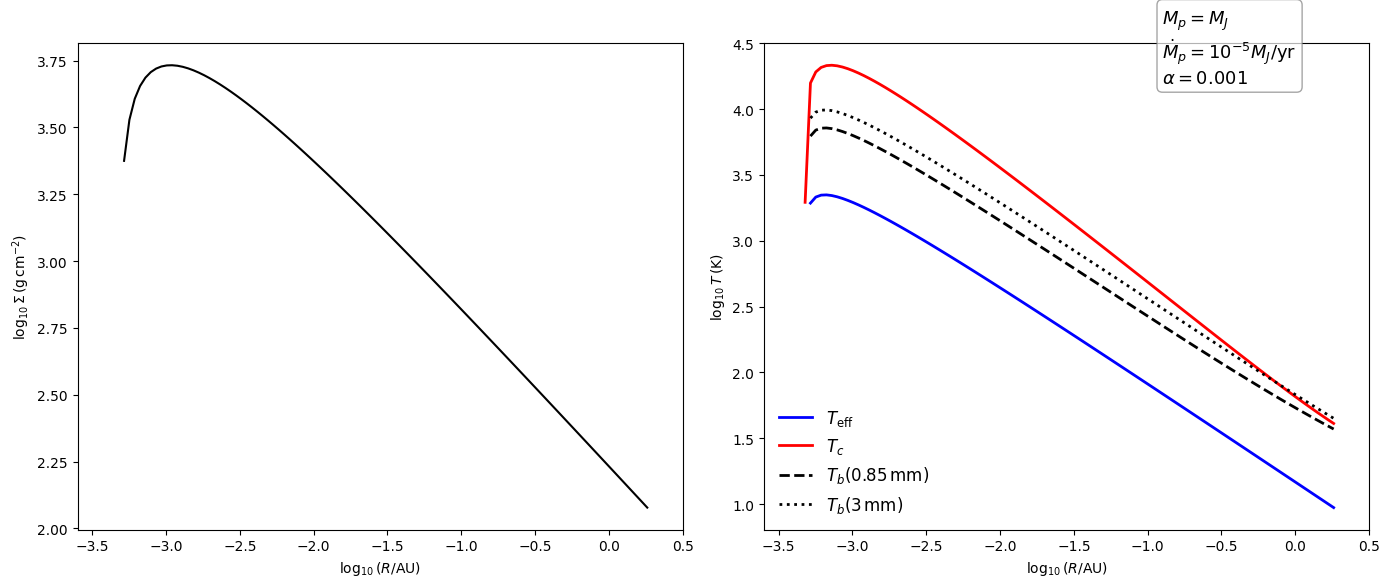

In [9]:
# Example usage with your parameters
if __name__ == "__main__":

    # Disk parameters
    Mp = 1.0 
    Mdot = 1e-5 
    alpha = 1e-3
    kappaR = 10.0
    Rin = 1.0 
    Rout = 1.85 
    d = 140

    Mp_label = r'$M_p = M_J$'
    Mdot_label = r'$\dot{M}_p = 10^{-5} M_J/\mathrm{yr}$'
    print(f'Given alpha = 0.0001, Rout = 1.86 au, MpMpdot = 1e-5:')
    # Calculate for main wavelength (e.g., 1.3mm)
    print(f'for 1.3 mm:')
    results = calculate_disk_properties(Mp = Mp , Mdot = Mdot, alpha = alpha, kappaR = kappaR, Rin = Rin, rp = 80, d_pc = d,
                                        lam_mm=1.3)
    # Calculate for 0.85mm
    print(f'\nfor 0.85 mm:')
    results_tb_085 = calculate_disk_properties(Mp = Mp, Mdot = Mdot, alpha = alpha, kappaR = kappaR, Rin = Rin, rp = 80, d_pc = d,
                                               lam_mm=0.85)
    # Calculate for 3mm
    print(f'\nfor 3 mm:')
    results_tb_3 = calculate_disk_properties(Mp = Mp, Mdot = Mdot, alpha = alpha, kappaR = kappaR, Rin = Rin, rp = 80, d_pc = d,
                                             lam_mm=3)

    # Plot
    plot_disk_profiles(results, results_tb_085, results_tb_3, alpha, Mp_label, Mdot_label)

C:\Users\LHEM\AppData\Local\Temp\ipykernel_30528\1437411937.py:27: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(R/AU), np.log10(Sigma6), label=r'$\Sigma_6$ (thick)', color='b')


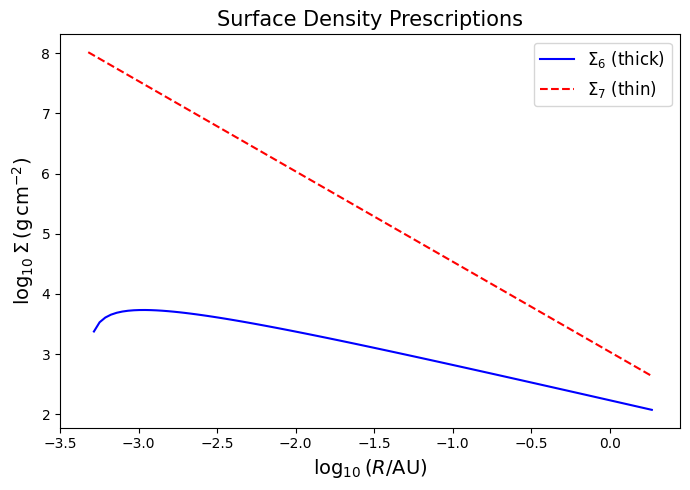

In [10]:
def plot_sigma6_vs_sigma7(Mp, Mdot, alpha, kappaR, Rin, Rout, mu=2.3):
    """
    Plot Sigma6 (optically thick) vs Sigma7 (optically thin) as a function of radius.

    """
    Mp = Mp * M_jup
    Mdot = Mdot * M_jup / sec_per_yr
    Rin = Rin * R_jup
    Rout = Rout * AU

    

    R = np.geomspace(Rin, Rout, 100)
    # Sigma6 (optically thick)
    term = (sigmaB * G * Mp * Mdot**3 / (alpha**4 * (np.pi**3) * kappaR))**0.2
    mu_term = (mu / Rgas)**0.8
    factor = (1 - np.sqrt(Rin/R))**(3/5)
    Sigma6 = ((2**(7/5)) / (3**(6/5))) * term * mu_term * factor * R**(-3/5)

    # Sigma7 (optically thin)
    Omega = np.sqrt(G * Mp / R**3)
    # For plotting, use T_ext = 10 K (ISM) as a simple reference
    T_ext = 10.0
    Sigma7 = (Mdot * mu * Omega) / (3.0 * np.pi * alpha * Rgas * T_ext)

    plt.figure(figsize=(7,5))
    plt.plot(np.log10(R/AU), np.log10(Sigma6), label=r'$\Sigma_6$ (thick)', color='b')
    plt.plot(np.log10(R/AU), np.log10(Sigma7), label=r'$\Sigma_7$ (thin)', color='r', linestyle='--')
    plt.xlabel(r'$\log_{10}(R/\mathrm{AU})$', fontsize=14)
    plt.ylabel(r'$\log_{10}\Sigma\,(\mathrm{g\,cm}^{-2})$', fontsize=14)
    plt.title('Surface Density Prescriptions', fontsize=15)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

plot_sigma6_vs_sigma7(1, 1e-5, 1e-3, 10, 1, 1.85)

L_irr = 1.39e-03 L_sun
Rout = 1.82 au
Tb_avg = 58.9 K
F_nu_tot = 1201.88 microJy


C:\Users\LHEM\AppData\Local\Temp\ipykernel_30528\1601346635.py:182: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R)  # g


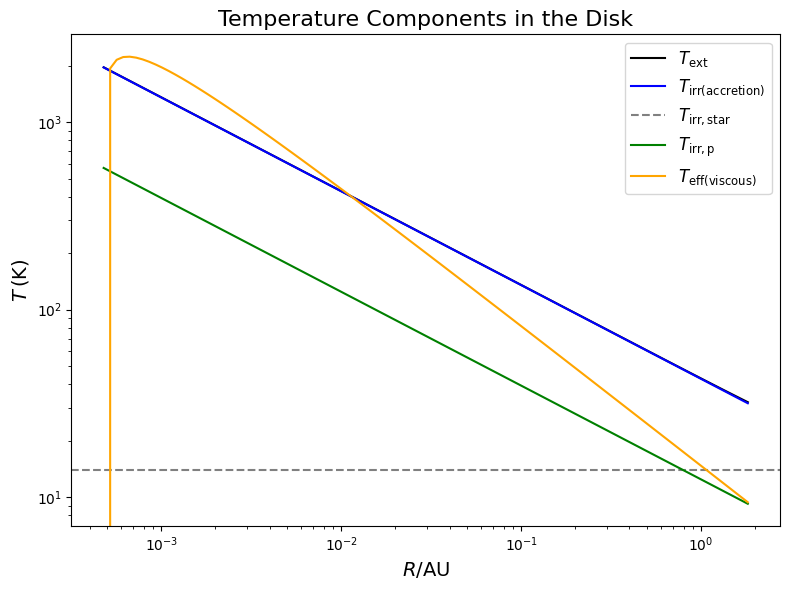

In [11]:
results = calculate_disk_properties(Mp = Mp , Mdot = Mdot, alpha = alpha, kappaR = kappaR, Rin = Rin, rp = 80, d_pc = d,
                                        lam_mm=1.3)
plot_temperature_components(results,  r'$M_p = M_J$', r'$\dot{M}_p = 10^{-5} M_J/\mathrm{yr}$', save_plot=False)

In [12]:
# Try importing it onto the CPD measurements to plot flux versus dust size 

# xcentroid ycentroid area max_value radius_au   (r90 = 72.9 AU)
# 1435.2160509756225 1343.8993475502016 470.0 5.076771442864703 165.37302792026688

# essentially estimate of flux for different disk radius
# what paremeters can be fixed? 
# obseved frequency of exoalma is 331.6 GHz （0.9 mm) from table 1 of exoalma
# R_out varies but R_out is a function of Mp and Mdot 
# total flux in the beam is 294.94 micro Jy

trial = calculate_disk_properties(1.67, Mp, Mdot, 0.1, kappaR, 1, 165, 149, 
                            mode="b", lam_mm=0.9, 
                            T_ISM=10.0, Lplanet=0.0, mu=2.3)


L_irr = 1.39e-03 L_sun
Rout = 3.16 au
Tb_avg = 2.4 K
F_nu_tot = 277.49 microJy


C:\Users\LHEM\AppData\Local\Temp\ipykernel_30528\1601346635.py:182: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R)  # g


result = calculate_disk_properties(1.52, Mp, Mdot, 0.1, kappaR, 1, 165, 195, 
                            mode="b", lam_mm=0.9, 
                            T_ISM=10.0, Lplanet=0.0, mu=2.3)
    F_nu_tot = result['F_nu_tot']


for 0.9 mm (exoALMA observing wavelength):
L_irr = 5.57e-03 L_sun
Rout = 5.02 au
Tb_avg = 2.4 K
F_nu_tot = 699.29 microJy


L_irr = 1.39e-06 L_sun
Rout = 0.32 au
Tb_avg = 2.3 K
F_nu_tot = 2.64 microJy
L_irr = 1.15e-04 L_sun
Rout = 1.38 au
Tb_avg = 2.4 K
F_nu_tot = 52.29 microJy
L_irr = 2.29e-04 L_sun
Rout = 1.73 au
Tb_avg = 2.4 K
F_nu_tot = 82.89 microJy
L_irr = 3.42e-04 L_sun
Rout = 1.98 au
Tb_avg = 2.4 K
F_nu_tot = 108.58 microJy
L_irr = 4.56e-04 L_sun
Rout = 2.18 au
Tb_avg = 2.4 K
F_nu_tot = 131.56 microJy
L_irr = 5.69e-04 L_sun
Rout = 2.35 au
Tb_avg = 2.4 K
F_nu_tot = 152.72 microJy
L_irr = 6.83e-04 L_sun
Rout = 2.50 au
Tb_avg = 2.4 K
F_nu_tot = 172.40 microJy
L_irr = 7.97e-04 L_sun
Rout = 2.63 au
Tb_avg = 2.4 K
F_nu_tot = 191.02 microJy
L_irr = 9.10e-04 L_sun
Rout = 2.75 au
Tb_avg = 2.4 K
F_nu_tot = 208.93 microJy
L_irr = 1.02e-03 L_sun
Rout = 2.86 au
Tb_avg = 2.4 K
F_nu_tot = 225.97 microJy
L_irr = 1.14e-03 L_sun
Rout = 2.96 au
Tb_avg = 2.4 K
F_nu_tot = 242.37 microJy
L_irr = 1.2

<>:47: SyntaxWarning: invalid escape sequence '\o'
<>:47: SyntaxWarning: invalid escape sequence '\o'
C:\Users\LHEM\AppData\Local\Temp\ipykernel_30528\1148964357.py:47: SyntaxWarning: invalid escape sequence '\o'
  ax2.set_ylabel('Dust Mass (M$_\oplus$)')
C:\Users\LHEM\AppData\Local\Temp\ipykernel_30528\1601346635.py:182: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R)  # g


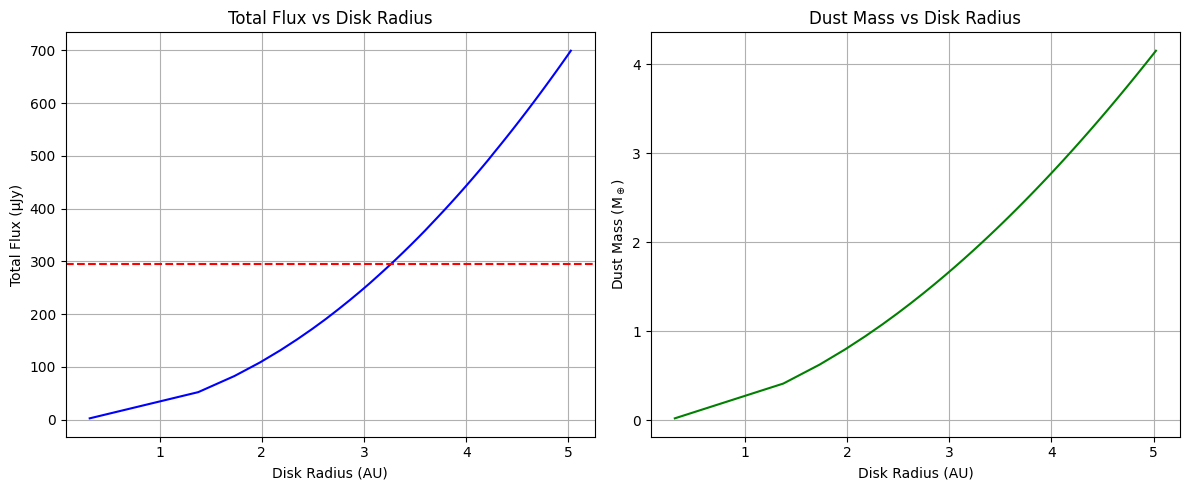

In [18]:
# the catalog show the signal to noise maximum value , not the maximum mu Jy so maybe need change the code a bit 

# Now create an array to vary Mp from 1 to 20 M_jup 
# Obtain an array of F_nu_tot and plot the plot 

# dust mass for the source: 
print(f'for 0.9 mm (exoALMA observing wavelength):')
# spec_flux=294.94

M_dust_source = calculate_disk_properties(1.67, Mp, Mdot, 0.1, kappaR, 1, 165, 149, 
                            mode="b", lam_mm=0.9, 
                            T_ISM=10.0, Lplanet=1e-5, mu=2.3, spec_flux=None)


print(f'\n')

Mp_array = np.linspace(0.001, 4, 50)  # from 1 to 13 M_jup (limit of brown dward)
F_nu_tot_array = []
Rout_array = []
M_dust_array = []



for Mp in Mp_array:
    result = calculate_disk_properties(1.67, Mp, Mdot, 0.1, kappaR, 1, 165, 149, 
                            mode="b", lam_mm=0.9, 
                            T_ISM=10.0, Lplanet=1e-5, mu=2.3)
    F_nu_tot = result['F_nu_tot']
    F_nu_tot_array.append(F_nu_tot)
    Rout = result['Rout']
    Rout_array.append(Rout)
    M_dust = result['M_dust']
    M_dust_array.append(M_dust)

# Plotting side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(Rout_array, F_nu_tot_array, color='blue')
ax1.set_xlabel('Disk Radius (AU)')
ax1.set_ylabel('Total Flux (μJy)')
ax1.set_title('Total Flux vs Disk Radius')
ax1.axhline(y=294.94, color='red', linestyle='--')
ax1.grid()

ax2.plot(Rout_array, M_dust_array, color='green')
ax2.set_xlabel('Disk Radius (AU)')
ax2.set_ylabel('Dust Mass (M$_\oplus$)')
ax2.set_title('Dust Mass vs Disk Radius')
#ax2.axhline(y=1.0895471654752764e-09, color='red', linestyle='--')
ax2.grid()

plt.tight_layout()
plt.show()


In [14]:
print(52266/470)

111.20425531914894


C:\Users\LHEM\AppData\Local\Temp\ipykernel_30528\1437411937.py:27: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(R/AU), np.log10(Sigma6), label=r'$\Sigma_6$ (thick)', color='b')


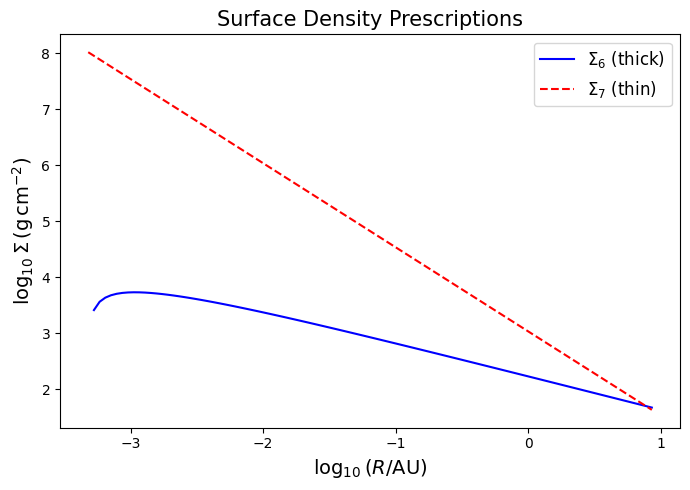

In [19]:
plot_sigma6_vs_sigma7(1, 1e-5, 1e-3, 10, 1, 8.59, mu=2.3)




C:\Users\LHEM\AppData\Local\Temp\ipykernel_30528\984882785.py:182: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R)  # g


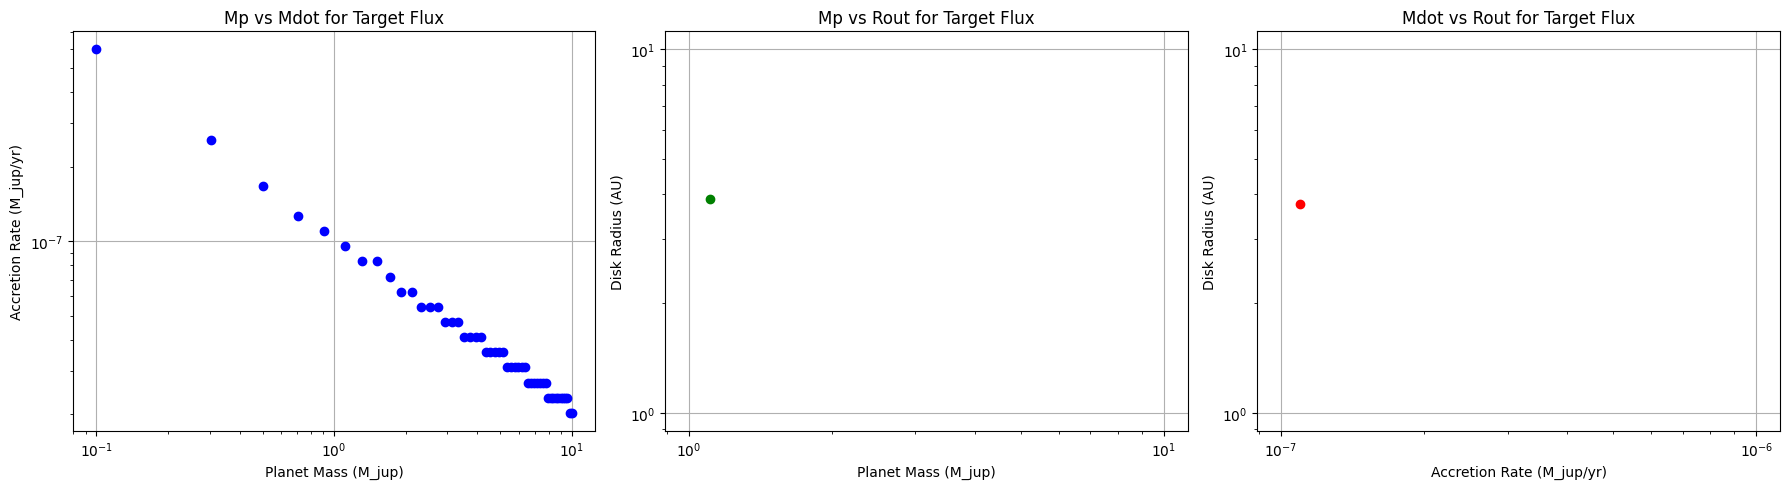

In [ ]:
# Plot parameter comparisons
# For a fix flux, what are the possible combinations of Mp, Mdot, Disk Radius 
# Input flux and a grid of Mp -> output Mdot for each Mp 
# Alter the spec flux function a little bit
# Conceptually how to reverse eveything 



Mp_grid = np.linspace(0.1, 10, 50)   # Example: 0.1 to 10 M_jup
Mdot_grid = np.logspace(-8, -5, 50)  # Example: 1e-7 to 1e-5 M_jup/yr
target_flux = 300  # microJy
tolerance = 20  # microJy
results_MpMdot = []
results_MpRout = []
results_MdotRout = []

# Plot 1:  Mp vs Mdot for a fixed flux
for Mp in Mp_grid:
    for Mdot in Mdot_grid:
        out_MpMdot = calculate_disk_properties(Mp=Mp, Mdot=Mdot, alpha = 1e-3, kappaR = 10 , Rin = 1, rp = 165, d_pc = 149, 
                            mode="b", lam_mm=0.9, 
                            T_ISM=10.0, Lplanet=1e-5, mu=2.3, spec_flux=None)


        if abs(out_MpMdot['F_nu_tot'] - target_flux) < tolerance:  
            results_MpMdot.append((Mp, Mdot, out_MpMdot['F_nu_tot']))


# Plot 2: Mp vs Rout for a fixed flux (fix Mdot as 1e-7 M_jup/yr)

for Mp in Mp_grid:
    Mdot = 1e-7  # fixed accretion rate
    out_MpRout = calculate_disk_properties(Mp=Mp, Mdot=Mdot, alpha = 1e-3, kappaR = 10 , Rin = 1, rp = 165, d_pc = 149, 
                        mode="b", lam_mm=0.9, 
                        T_ISM=10.0, Lplanet=1e-5, mu=2.3, spec_flux=None)
    if abs(out_MpRout['F_nu_tot'] - target_flux) < tolerance:  
        results_MpRout.append((Mp, out_MpRout['Rout'], out_MpRout['F_nu_tot']))


# Plot 3: Mdot vs Rout for a fixed flux (Rout dependent on Mp )

for Mdot in Mdot_grid:
    Mp = 1.0  # fixed planet mass
    out_MdotRout = calculate_disk_properties(Mp=Mp, Mdot=Mdot, alpha = 1e-3, kappaR = 10 , Rin = 1, rp = 165, d_pc = 149, 
                        mode="b", lam_mm=0.9, 
                        T_ISM=10.0, Lplanet=1e-5, mu=2.3, spec_flux=None)
    if abs(out_MdotRout['F_nu_tot'] - target_flux) < tolerance:
        results_MdotRout.append((Mdot, out_MdotRout['Rout'], out_MdotRout['F_nu_tot']))

# Plotting all the results in one row of subplots as 
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
# Plot 1: Mp vs Mdot
if results_MpMdot:
    results_MpMdot = np.array(results_MpMdot)
    ax1.plot(results_MpMdot[:, 0], results_MpMdot[:, 1], "o", color='blue')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel('Planet Mass (M_jup)')
    ax1.set_ylabel('Accretion Rate (M_jup/yr)')
    ax1.set_title('Mp vs Mdot for Target Flux')
    ax1.grid(True)
# Plot 2: Mp vs Rout
if results_MpRout:
    results_MpRout = np.array(results_MpRout)
    ax2.plot(results_MpRout[:, 0], results_MpRout[:, 1], "o",color='green')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xlabel('Planet Mass (M_jup)')
    ax2.set_ylabel('Disk Radius (AU)')
    ax2.set_title('Mp vs Rout for Target Flux')
    ax2.grid(True)
# Plot 3: Mdot vs Rout
if results_MdotRout:
    results_MdotRout = np.array(results_MdotRout)
    ax3.plot(results_MdotRout[:, 0], results_MdotRout[:, 1], "o", color='red')
    ax3.set_xscale('log')
    ax3.set_yscale('log')
    ax3.set_xlabel('Accretion Rate (M_jup/yr)')
    ax3.set_ylabel('Disk Radius (AU)')
    ax3.set_title('Mdot vs Rout for Target Flux')
    ax3.grid(True)
plt.tight_layout()
plt.show()



C:\Users\LHEM\AppData\Local\Temp\ipykernel_30528\984882785.py:182: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R)  # g


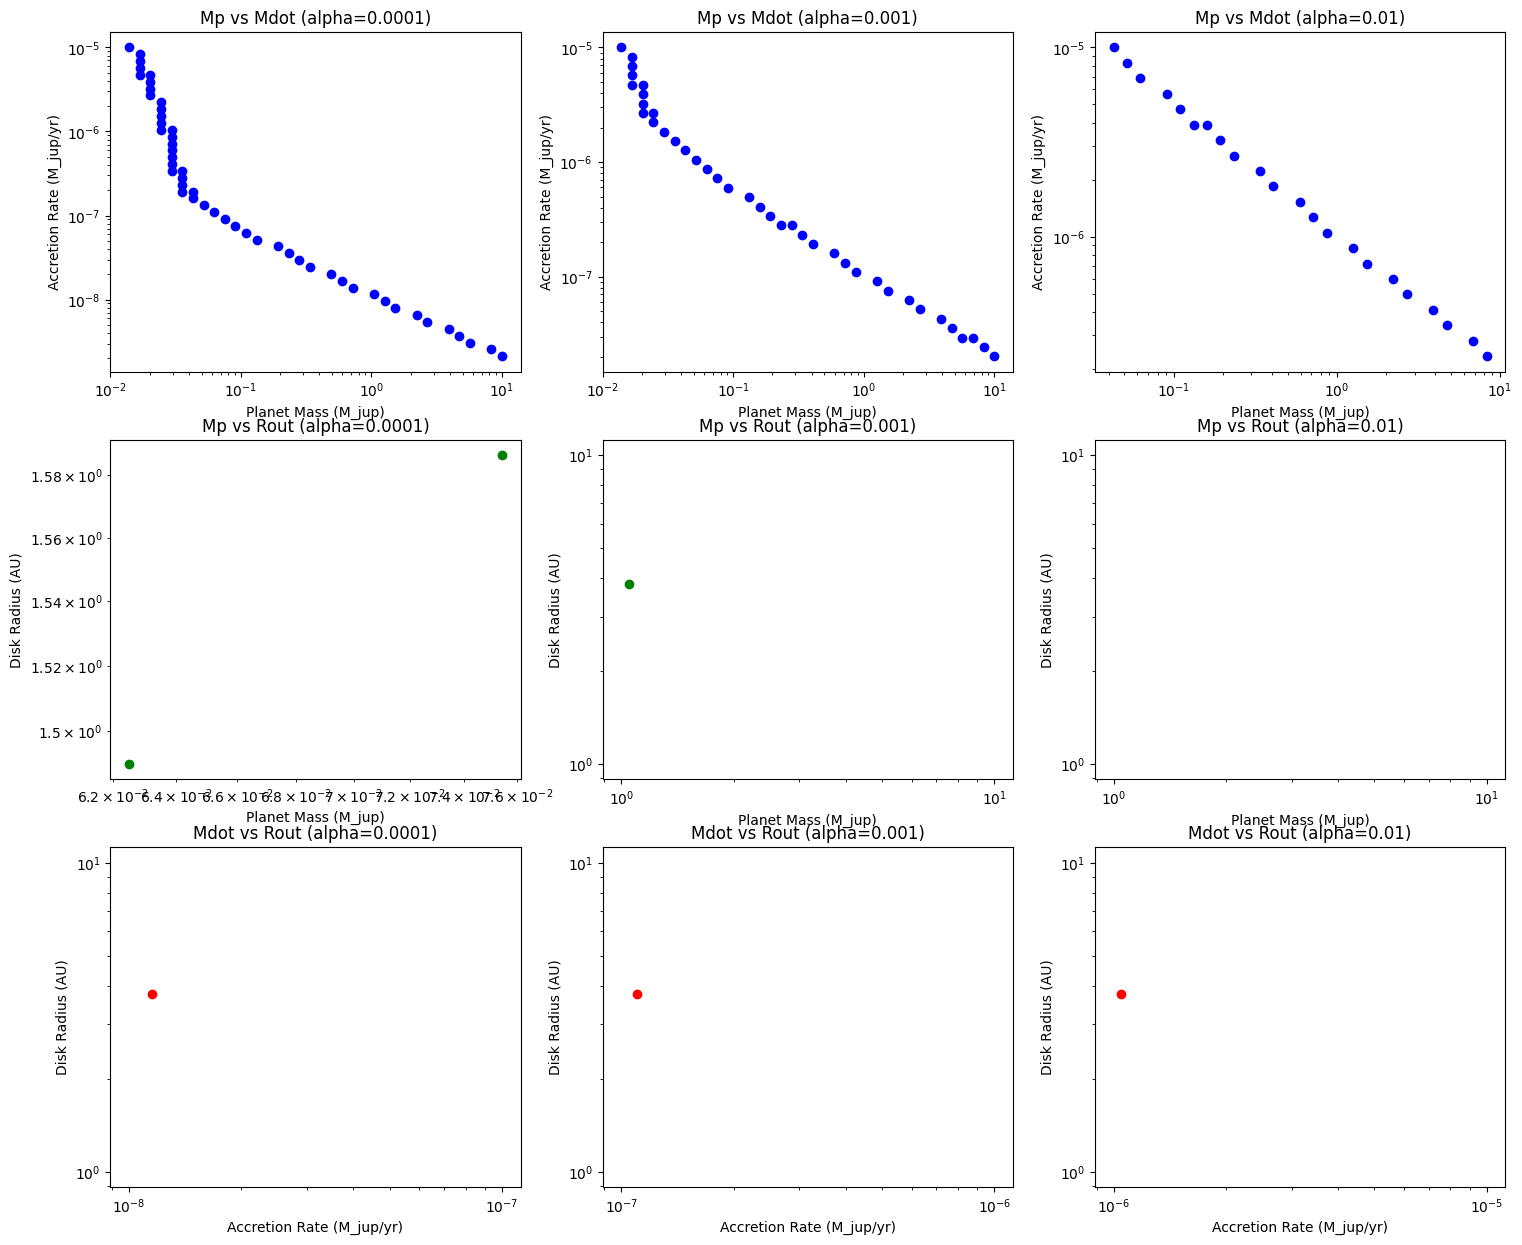

In [ ]:
# investigate the effect of alpha on the flux
alpha_grid = [1e-4, 1e-3, 1e-2]
Mp_grid = np.logspace(-3, 1, 50)
Mdot_grid = np.logspace(-9, -5, 50)
target_flux = 300  # microJy
tolerance = 20  # microJy

# maybe from plot 1 finds the range of Mp and Mdot that can produce the target flux
# then use that range to plot the other two plots instead of fixing Mp and Mdot to one value, just plot it as scatter points to see how close the flux lies to the target flux

fig, axes = plt.subplots(3, len(alpha_grid), figsize=(6*len(alpha_grid), 15))

for col, alpha in enumerate(alpha_grid):
    results_MpMdot = []
    results_MpRout = []
    results_MdotRout = []

    # Plot 1: Mp vs Mdot for a fixed flux
    for Mp in Mp_grid:
        for Mdot in Mdot_grid:
            out = calculate_disk_properties(Mp=Mp, Mdot=Mdot, alpha=alpha, kappaR=10, Rin=1, rp=165, d_pc=149,
                                            mode="b", lam_mm=0.9, T_ISM=10.0, Lplanet=1e-5, mu=2.3)
            if abs(out['F_nu_tot'] - target_flux) < tolerance:
                results_MpMdot.append((Mp, Mdot, out['F_nu_tot']))

    # Plot 2: Mp vs Rout for a fixed flux (fix Mdot as 1e-7 M_jup/yr)
    for Mp in Mp_grid:
        Mdot = 1e-7
        out = calculate_disk_properties(Mp=Mp, Mdot=Mdot, alpha=alpha, kappaR=10, Rin=1, rp=165, d_pc=149,
                                        mode="b", lam_mm=0.9, T_ISM=10.0, Lplanet=1e-5, mu=2.3)
        if abs(out['F_nu_tot'] - target_flux) < tolerance:
            results_MpRout.append((Mp, out['Rout'], out['F_nu_tot']))

    # Plot 3: Mdot vs Rout for a fixed flux (Rout dependent on Mp)
    for Mdot in Mdot_grid:
        Mp = 1.0
        out = calculate_disk_properties(Mp=Mp, Mdot=Mdot, alpha=alpha, kappaR=10, Rin=1, rp=165, d_pc=149,
                                        mode="b", lam_mm=0.9, T_ISM=10.0, Lplanet=1e-5, mu=2.3)
        if abs(out['F_nu_tot'] - target_flux) < tolerance:
            results_MdotRout.append((Mdot, out['Rout'], out['F_nu_tot']))

    # Plotting
    ax1, ax2, ax3 = axes[0, col], axes[1, col], axes[2, col]
    if results_MpMdot:
        arr = np.array(results_MpMdot)
        ax1.plot(arr[:, 0], arr[:, 1], "o", color='blue')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel('Planet Mass (M_jup)')
    ax1.set_ylabel('Accretion Rate (M_jup/yr)')
    ax1.set_title(f'Mp vs Mdot (alpha={alpha})')
    #ax1.grid(True)

    if results_MpRout:
        arr = np.array(results_MpRout)
        ax2.plot(arr[:, 0], arr[:, 1], "o", color='green')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xlabel('Planet Mass (M_jup)')
    ax2.set_ylabel('Disk Radius (AU)')
    ax2.set_title(f'Mp vs Rout (alpha={alpha})')
    #ax2.grid(True)

    if results_MdotRout:
        arr = np.array(results_MdotRout)
        ax3.plot(arr[:, 0], arr[:, 1], "o", color='red')
    ax3.set_xscale('log')
    ax3.set_yscale('log')
    ax3.set_xlabel('Accretion Rate (M_jup/yr)')
    ax3.set_ylabel('Disk Radius (AU)')
    ax3.set_title(f'Mdot vs Rout (alpha={alpha})')
    #ax3.grid(True)

#plt.tight_layout()
plt.show()

C:\Users\LHEM\AppData\Local\Temp\ipykernel_30528\984882785.py:182: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R)  # g


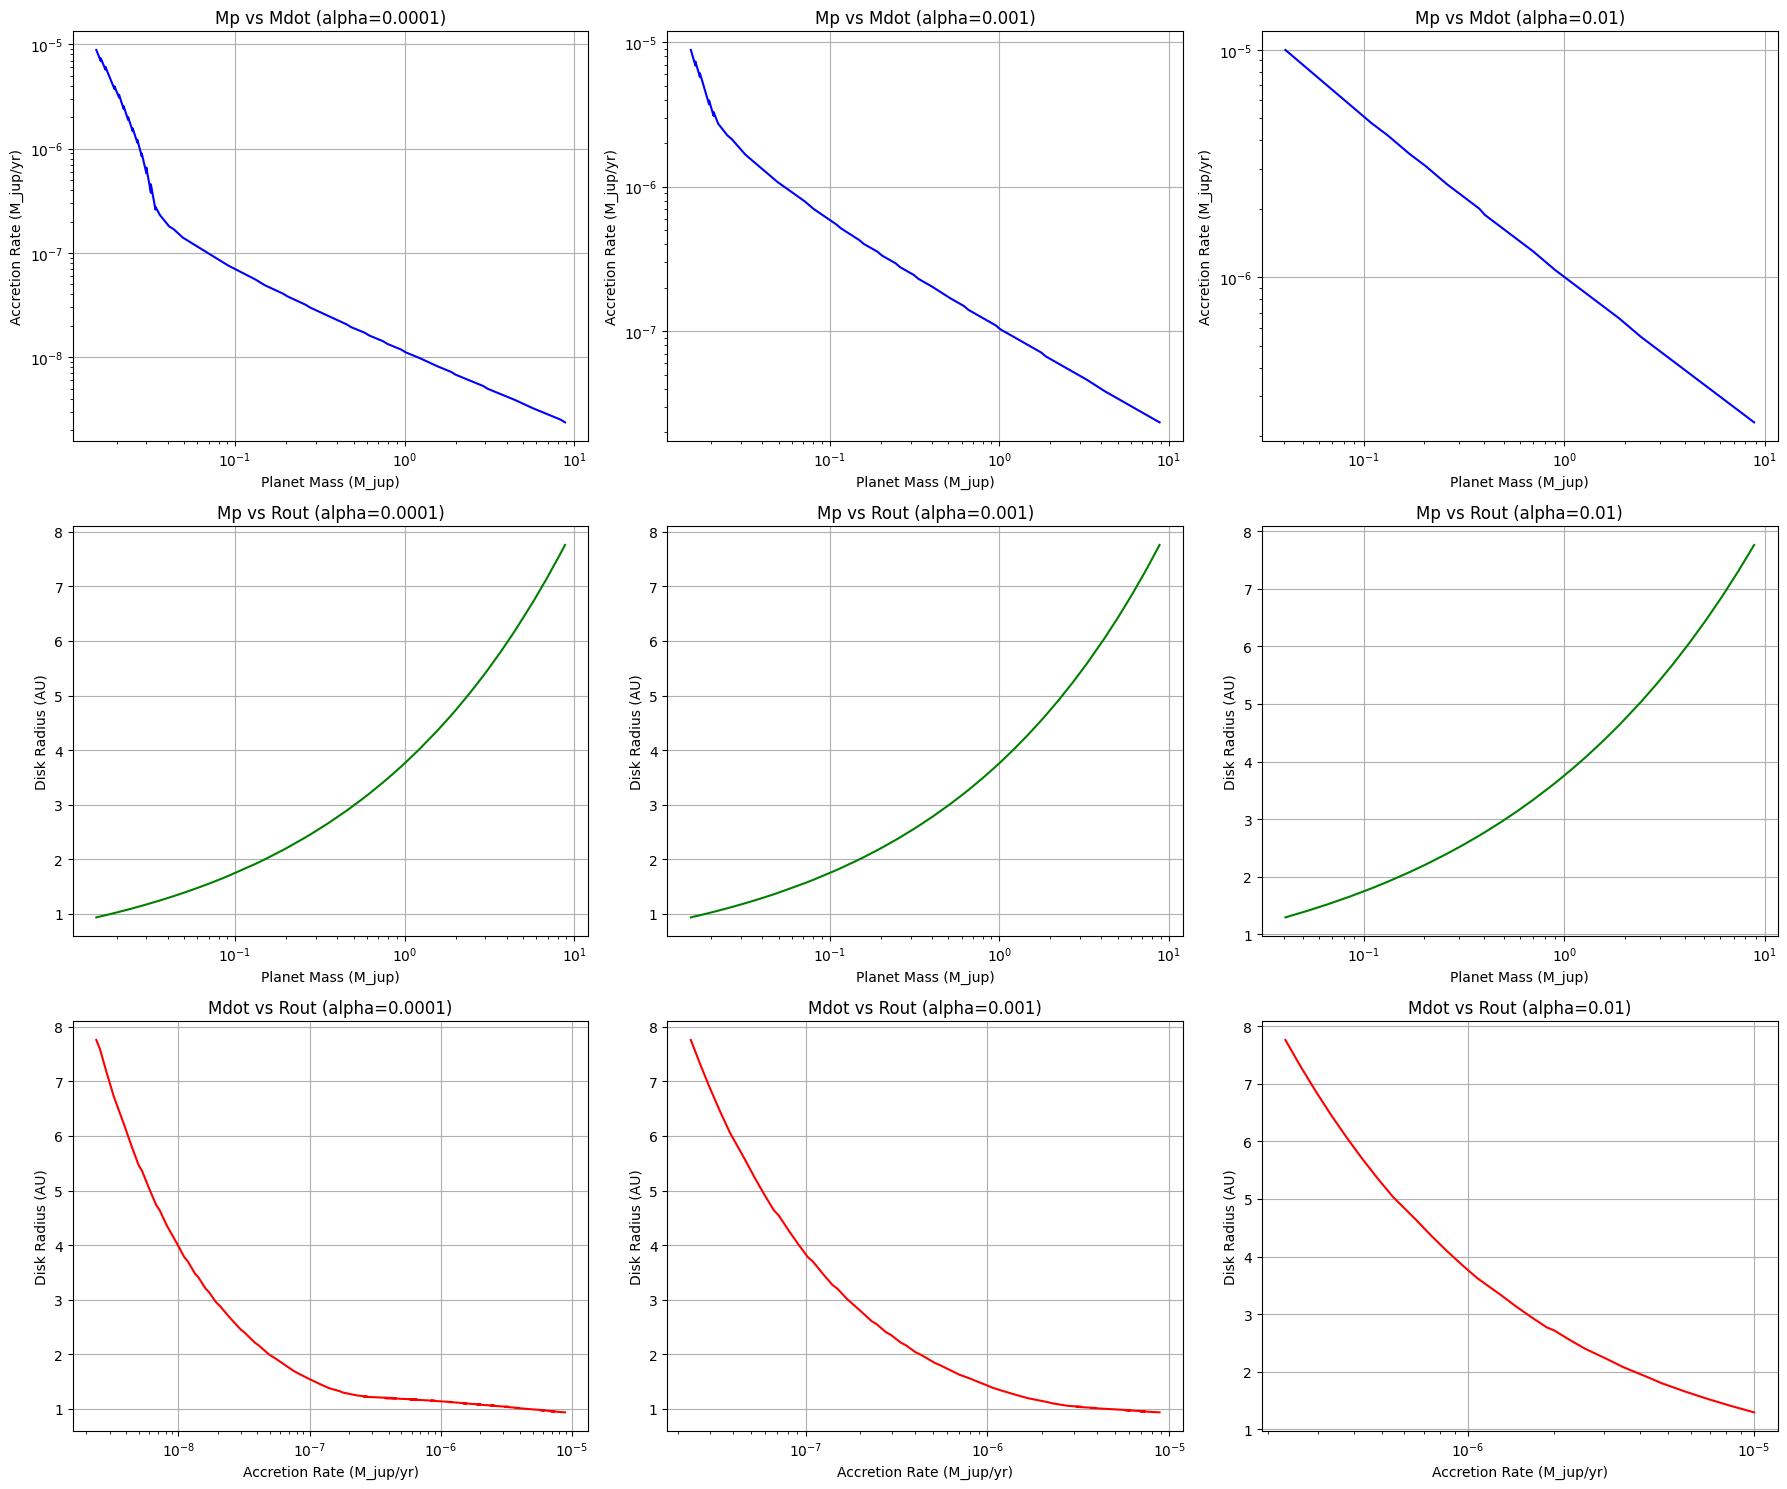

In [46]:
# The issue is because for this given flux , Mp must be around 10^-7, Mp to Rout is a 1 to 1 mapping, Mdot to Rout ... i mean if I fixed Mp...mp is really sensitive to accretion rate thats why 
# The arrays doesnt have to be the same size 
# I need to figure out the issue 

alpha_grid = [1e-4, 1e-3, 1e-2]
Mp_grid = np.logspace(-3, 1, 150)
Mdot_grid = np.logspace(-9, -5, 150)
target_flux = 300  # microJy
tolerance = 3  # microJy

fig, axes = plt.subplots(3, len(alpha_grid), figsize=(6*len(alpha_grid), 15))

for col, alpha in enumerate(alpha_grid):
    solutions = []
    for Mp in Mp_grid:
        for Mdot in Mdot_grid:
            out = calculate_disk_properties(Mp=Mp, Mdot=Mdot, alpha=alpha, kappaR=10, Rin=1, rp=165, d_pc=149,
                                            mode="b", lam_mm=0.9, T_ISM=10.0, Lplanet=1e-5, mu=2.3)
            if abs(out['F_nu_tot'] - target_flux) < tolerance:
                solutions.append((Mp, Mdot, out['Rout'], out['F_nu_tot']))

    solutions = np.array(solutions)
    ax1, ax2, ax3 = axes[0, col], axes[1, col], axes[2, col]

    if len(solutions) > 0:
        # Mp vs Mdot
        #ax1.scatter(solutions[:, 0], solutions[:, 1], c=solutions[:, 3], cmap='Blues', s=20)
        ax1.plot(solutions[:, 0], solutions[:, 1], color='blue')
        ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlabel('Planet Mass (M_jup)')
        ax1.set_ylabel('Accretion Rate (M_jup/yr)')
        ax1.set_title(f'Mp vs Mdot (alpha={alpha})')
        ax1.grid(True)

        # Mp vs Rout
        #ax2.scatter(solutions[:, 0], solutions[:, 2], c=solutions[:, 3], cmap='Greens', s=20)
        ax2.plot(solutions[:, 0], solutions[:, 2], color='green')
        ax2.set_xscale('log')
        ax2.set_xlabel('Planet Mass (M_jup)')
        ax2.set_ylabel('Disk Radius (AU)')
        ax2.set_title(f'Mp vs Rout (alpha={alpha})')
        ax2.grid(True)

        # Mdot vs Rout
        #ax3.scatter(solutions[:, 1], solutions[:, 2], c=solutions[:, 3], cmap='Reds', s=20)
        ax3.plot(solutions[:, 1], solutions[:, 2], color='red')
        ax3.set_xscale('log')
        ax3.set_xlabel('Accretion Rate (M_jup/yr)')
        ax3.set_ylabel('Disk Radius (AU)')
        ax3.set_title(f'Mdot vs Rout (alpha={alpha})')
        ax3.grid(True)

plt.tight_layout()
plt.show()

#### Notes from the plot

With increasing viscosity

In [ ]:
# Make the plots again to streamline the process

from joblib import Parallel, delayed

def run_model(Mp, Mdot, alpha):
    out = calculate_disk_properties(Mp=Mp, Mdot=Mdot, alpha=alpha, kappaR=10, Rin=1, rp=165, d_pc=149,
                                    mode="b", lam_mm=0.9, T_ISM=10.0, Lplanet=1e-5, mu=2.3)
    if abs(out['F_nu_tot'] - target_flux) < tolerance:
        return (alpha, Mp, Mdot, out['Rout'])
    return None

results = Parallel(n_jobs=-1)(delayed(run_model)(Mp, Mdot, alpha)
                              for alpha in alpha_grid
                              for Mp in Mp_grid
                              for Mdot in Mdot_grid)
results = [r for r in results if r is not None]


